In [21]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 
import mysql.connector 
import numpy as np 


db = mysql.connector.connect(
    host='localhost',
    user='root',
    password='artist28327',
    database='ecommerce'
) 

cur = db.cursor() 

# List all the Unique cities where Customers are Located

In [10]:
query = ''' select distinct customer_city from customers '''

cur.execute(query) 
data = cur.fetchall() 
data 

[('franca',),
 ('sao bernardo do campo',),
 ('sao paulo',),
 ('mogi das cruzes',),
 ('campinas',),
 ('jaragua do sul',),
 ('timoteo',),
 ('curitiba',),
 ('belo horizonte',),
 ('montes claros',),
 ('rio de janeiro',),
 ('lencois paulista',),
 ('caxias do sul',),
 ('piracicaba',),
 ('guarulhos',),
 ('pacaja',),
 ('florianopolis',),
 ('aparecida de goiania',),
 ('santo andre',),
 ('goiania',),
 ('cachoeiro de itapemirim',),
 ('sao jose dos campos',),
 ('sao roque',),
 ('camacari',),
 ('resende',),
 ('sumare',),
 ('novo hamburgo',),
 ('sao luis',),
 ('sao jose',),
 ('santa barbara',),
 ('ribeirao preto',),
 ('ituiutaba',),
 ('taquarituba',),
 ('sao jose dos pinhais',),
 ('barrinha',),
 ('parati',),
 ('dourados',),
 ('trindade',),
 ('cascavel',),
 ('fortaleza',),
 ('brasilia',),
 ('pelotas',),
 ('porto alegre',),
 ('salto',),
 ('jundiai',),
 ('cacapava',),
 ('sao vicente',),
 ('uberlandia',),
 ('botelhos',),
 ('sao goncalo',),
 ('araucaria',),
 ('nova iguacu',),
 ('areia branca',),
 ('campo

# Count the number of orders placed in 2017 

In [13]:
query = ''' select count(order_id) from orders where year(order_purchase_timestamp) =2017; '''

cur.execute(query) 
data = cur.fetchall() 
'Total orders placed in 2017 are',data[0][0] 

('Total orders placed in 2017 are', 45101)

# Find the Total sales per category.

In [10]:
query = ''' select upper(products.product_category) category,
round(sum(payments.payment_value),2) sales 
from products join order_items
on products.product_id = order_items.product_id
join payments 
on payments.order_id = order_items.order_id
group by category 
''' 
cur.execute(query) 
data = cur.fetchall() 
# data 
df = pd.DataFrame(data, columns = ['Product','Category']) 
df

,Product,Category
0,PERFUMERY,506738.66
1,FURNITURE DECORATION,1430176.39
2,TELEPHONY,486882.05
3,BED TABLE BATH,1712553.67
4,AUTOMOTIVE,852294.33
...,...,...
69,CDS MUSIC DVDS,1199.43
70,LA CUISINE,2913.53
71,FASHION CHILDREN'S CLOTHING,785.67
72,PC GAMER,2174.43


# calculate the percentage of orders that were paid in installments.

In [7]:
query = ''' select (sum(CASE WHEN payment_installments >= 1 THEN 1 else 0 END))/count(*)*100
from payments 
''' 
cur.execute(query) 
data = cur.fetchall() 
'the percentage of orders in installments are %',data[0][0] 


('the percentage of orders in installments are %', Decimal('99.9981'))

# Count the number of Cusomters from each state.

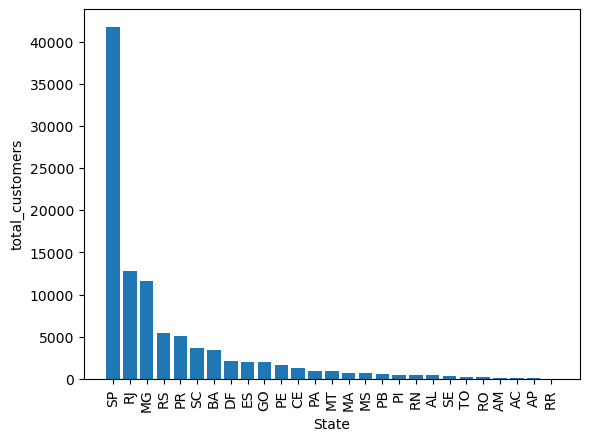

In [18]:
query = ''' select customer_state , count(customer_id) 
from customers group by customer_state
'''
cur.execute(query) 
data =cur.fetchall()
df=pd.DataFrame(data, columns = ['state','total_customers'])
df = df.sort_values(by='total_customers', ascending =False)
plt.bar(df['state'],df['total_customers']) 
plt.xticks(rotation = 90)
plt.xlabel('State') 
plt.ylabel('total_customers') 
plt.show() 

# Calculate the number of orders per month in 2018

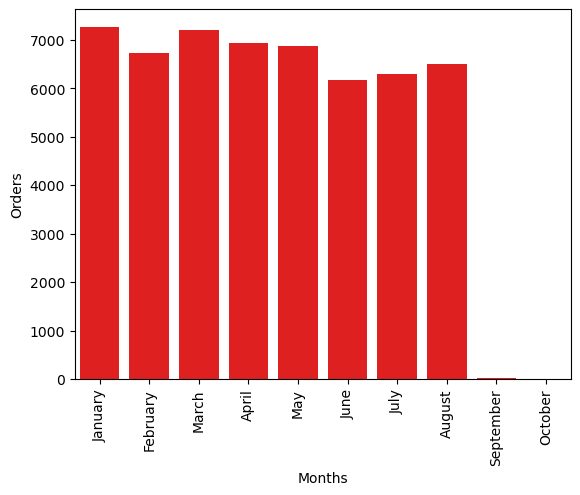

In [27]:
query = ''' select  monthname(order_purchase_timestamp) months , 
count(order_id) orders
from orders
where year(order_purchase_timestamp) =2018 
group by months 
'''
cur.execute(query) 
data  = cur.fetchall() 
df = pd.DataFrame(data, columns = ['Months','Orders']) 
o = ['January','February','March','April','May','June','July','August','September','October']
sns.barplot(x=df['Months'], y =df['Orders'], data = df, order = o,color = 'red')
plt.xticks(rotation = 90)
plt.show()

# Find the average number of products per order, grouped by customer city.

In [11]:
query = '''WITH count_per_order AS (
    SELECT 
        orders.order_id, 
        orders.customer_id,
        COUNT(order_items.order_id) AS oc
    FROM orders 
    JOIN order_items ON orders.order_id = order_items.order_id
    GROUP BY orders.order_id, orders.customer_id
)
SELECT 
    customers.customer_city, 
    AVG(count_per_order.oc) AS avg_items_per_order
FROM customers 
JOIN count_per_order ON customers.customer_id = count_per_order.customer_id 
GROUP BY customers.customer_city
order by avg_items_per_order desc
'''
cur.execute(query) 
data = cur.fetchall() 
df=pd.DataFrame(data, columns = ['customer_city' , 'average_orders']) 
df.head() 

,customer_city,average_orders
0,padre carvalho,7.0000
1,celso ramos,6.5000
2,datas,6.0000
3,candido godoi,6.0000
4,matias olimpio,5.0000


# Calculate the percentage of total revenue contributed by each product category 

In [17]:
query = ''' 
SELECT UPPER(products.product_category) AS category,
(SUM(payments.payment_value) / (SELECT SUM(payment_value) FROM payments)) * 100 AS sales_percentage
FROM products 
JOIN order_items ON products.product_id = order_items.product_id
JOIN payments ON payments.order_id = order_items.order_id
GROUP BY UPPER(products.product_category)
ORDER BY sales_percentage DESC
''' 

cur.execute(query) 
data = cur.fetchall() 
df = pd.DataFrame(data, columns = ['category', 'sales_percentage']) 
df

,category,sales_percentage
0,BED TABLE BATH,10.697529
1,HEALTH BEAUTY,10.352841
2,COMPUTER ACCESSORIES,9.902824
3,FURNITURE DECORATION,8.933649
4,WATCHES PRESENT,8.927654
...,...,...
69,PC GAMER,0.013583
70,HOUSE COMFORT 2,0.010685
71,CDS MUSIC DVDS,0.007492
72,FASHION CHILDREN'S CLOTHING,0.004908


# Identify the correlation between product price and the number of times a product has been purchased

In [9]:
query = ''' select products.product_category, 
count(order_items.product_id), 
round(avg(order_items.price),2)
from products join order_items 
on products.product_id = order_items.product_id 
group by products.product_category
''' 
cur.execute(query) 
data = cur.fetchall() 

df= pd.DataFrame(data, columns = ['Products','Order_Count','Price']) 
df.head() 

arr1 = df['Order_Count'] 
arr2 = df['Price'] 
np.corrcoef([arr1,arr2]) 


array([[ 1.        , -0.10631514],
       [-0.10631514,  1.        ]])

# Calculate the total revenue of each seller

In [16]:
query = ''' select order_items.seller_id , sum(payments.payment_value) 
from order_items join payments
 on order_items.order_id = payments.order_id
group by order_items.seller_id

'''

cur.execute(query) 
data = cur.fetchall() 
df=pd.DataFrame(data, columns = ['Seller_ID', 'Revenue']) 
df.head() 

,Seller_ID,Revenue
0,dd7ddc04e1b6c2c614352b383efe2d36,16061.360107
1,cc419e0650a3c5ba77189a1882b7556a,141309.580055
2,1f50f920176fa81dab994f9023523100,290253.420128
3,822bad9bc42b51213ba522fe87b7ab5d,5774.740028
4,cea729054f157f5870bdd321a958d994,3458.130013


# Calculate the total sales year by year

In [24]:
query = ''' select year(orders.order_purchase_timestamp) as years,
round(sum(payments.payment_value),2)as payment from orders
join payments
on orders.order_id = payments.order_id
group by years order by years
'''
cur.execute(query) 
data = cur.fetchall()
df = pd.DataFrame(data, columns = ['Years','Sales']) 
df

,Years,Sales
0,2016,59362.34
1,2017,7249746.73
2,2018,8699763.05
